# Employee satisfaction alpha — a quantitative teardown 🔬
### The CAPM-alpha Newey-West/OLS split · a random survivor-basket placebo · a first/second-half persistence cut · a costed long-only timer · a 20-seed synthetic power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Persist%3F: Busted](https://img.shields.io/badge/Persist%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **Edmans (2011): a "100 Best Companies to Work For" portfolio earns positive risk-adjusted alpha** — is tested here as a held equal-weight basket vs the market, with two caps stated up front: the basket is **hand-picked from known survivors** (survivorship on the Signal axis) and we run a **CAPM (market-only) alpha, not a 4-factor alpha**, so any positive alpha is an *upper bound*.

> ⚠️ **Data note.** yfinance daily total-return closes → monthly, 2016-01-31 → 2026-06-30 (126 months), 17 listed perennial members + SPY + a 34-name survivor placebo pool, cached. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `4116fe2691f7`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from employee_satisfaction import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    MONTHLY, BASKET_PRESENT, CONTROL_PRESENT = data.load_real()
    BASKET = st.equal_weight_basket(MONTHLY, BASKET_PRESENT)
    MARKET = MONTHLY[data.MARKET]
else:
    MONTHLY = BASKET_PRESENT = CONTROL_PRESENT = BASKET = MARKET = None
print("real cache present:", HAVE_REAL, "| basket names:",
      (0 if BASKET_PRESENT is None else len(BASKET_PRESENT)),
      "| months:", (0 if MONTHLY is None else len(MONTHLY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2016-01-31', 'end': '2026-06-30', 'n_months': 126, 'n_names': 17, 'basket_ann': 20.16, 'market_ann': 15.02, 'basket_vol': 19.4, 'market_vol': 15.2, 'alpha_monthly_bps': 23.2, 'alpha_ann': 2.82, 'beta': 1.15, 't_alpha_nw': 1.1, 't_alpha_ols': 1.06, 'excess_mean_bps': 42.8, 'excess_t_nw': 1.9, 'excess_t_ols': 1.96, 'ir': 0.6, 'hit': 74, 'hit_pct': 58.7, 'wilson': (50.0, 66.9), 'placebo_mean': 0.2, 'placebo_sd': 1.18, 'placebo_n': 5000, 'placebo_p': 0.013, 'placebo_k': 17, 'early_alpha': 8.12, 'early_t': 2.77, 'early_n': 63, 'late_alpha': -2.25, 'late_t': -0.59, 'late_n': 63, 'to_pct': 2.4, 'drag5': 0.01, 'drag10': 0.03, 'net5_alpha': 2.81, 'net5_t': 1.1, 'net10_alpha': 2.79, 'net10_t': 1.09, 'syn_null_mean': -0.07, 'syn_null_sd': 0.96, 'syn_null_fire': 1, 'syn_planted_t': 2.99, 'syn_planted_alpha': 3.98, 'fp': '4116fe2691f7'}


real cache present: True | basket names: 17 | months: 126


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | CAPM α **+2.82%/yr** at NW **t = 1.10** (OLS 1.06), β = 1.15; excess-over-market NW t = 1.90; beats random survivor baskets (placebo p = 0.013) but survivor-picked + market-only control |
| **Tradability** | `MIRAGE` | turnover 2.4%/mo → cost drag 0.01%/yr; net α 2.81%/yr at t = 1.10 — no certified alpha; the +5pp/yr is β = 1.15 |
| **Persist?** | `BUSTED` | first half α +8.12%/yr (t = 2.77); second half -2.25%/yr (t = -0.59) |

> 💡 In plain words: the basket out-returns SPY, but at β = 1.15 that is mostly leverage; the risk-adjusted residual is sub-2, front-loaded into 2016-2021, and negative since — a weak, non-persistent signal on a survivor-picked basket.

## 1 · The claim, formalised

Let $r^B_t$ be the equal-weight basket's monthly total return and $r^M_t$ the market (SPY). Edmans' claim is a positive **risk-adjusted** intercept:

$$ r^B_t = \alpha + \beta\, r^M_t + \varepsilon_t, \qquad H_1:\ \alpha > 0. $$

- **H₁ (alpha).** $\alpha > 0$ with a HAC $t \ge 2$ — the satisfaction premium the paper reports.
- **H₂ (not just survivorship).** The basket's $\alpha$ exceeds that of random baskets drawn from a pool of large-cap survivors *not* chosen for workplace prestige.
- **H₃ (persistence).** $\alpha$ is present in both halves of the sample, not one lucky window.

We find **H₁ not supported** (NW t = 1.10 < 2; β = 1.15 absorbs most of the raw +5pp/yr), **H₂ supported** (placebo p = 0.013), **H₃ rejected** (early t = 2.77, late t = -0.59). The one check that *helps* the claim (H₂) is exactly the one that can't certify magnitude — a control sharing the survivorship bias speaks to *existence*, never to *size*.

## 2 · So what? — inference design

Monthly basket returns are mildly autocorrelated, so the primary is a **Newey-West (3-lag) HAC t** on the CAPM intercept, with a plain OLS t as a cross-check. We also read the **excess-over-market** series $d_t = r^B_t - r^M_t$ directly (mean, NW t, annualized information ratio) — a beta-agnostic 'does it beat the market' view — and put a **Wilson** interval on the monthly win-rate. The survivorship bias is not just named; it is **sized** by a 5,000-draw random survivor-basket placebo, and the persistence question is a **pre-declared** halving of the sample, not a snooped break-point.

## 3 · How we'd know — the protocol

- **Basket.** 17 listed perennial "100 Best" members, equal-weight, monthly rebalanced, 2016-01-31 → 2026-06-30 (126 months).
- **Headline.** CAPM α (NW + OLS t) + excess-over-market (NW t, IR) + Wilson win-rate.
- **Survivorship.** 5,000 random equal-weight baskets from a 34-name large-cap survivor pool not chosen for prestige; right-tail placebo p.
- **Persistence.** First-half vs second-half CAPM α, each with its own NW t.
- **Execution (timer).** Equal weights set at the month-end close, earn next month (calendar rebalance, zero look-ahead); cost = one-way × NAV × realised turnover; long-only, no borrow.
- **Control.** Synthetic monthly market + β·mkt + idio basket, plantable α knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline CAPM alpha and the excess series

The market model on 126 monthly returns; the intercept is the risk-adjusted alpha, the excess series is the beta-agnostic cross-check.

months 126
basket +20.16%/yr (vol 19.4%)  vs  market +15.02%/yr (vol 15.2%)
CAPM alpha +2.82%/yr (beta 1.15); NW t = +1.10, OLS t = +1.06
excess-over-market +42.8 bps/mo; NW t = +1.90, OLS t = +1.96, IR 0.60/yr
win-rate 74/126 = 58.7% Wilson [50.0%, 66.9%]


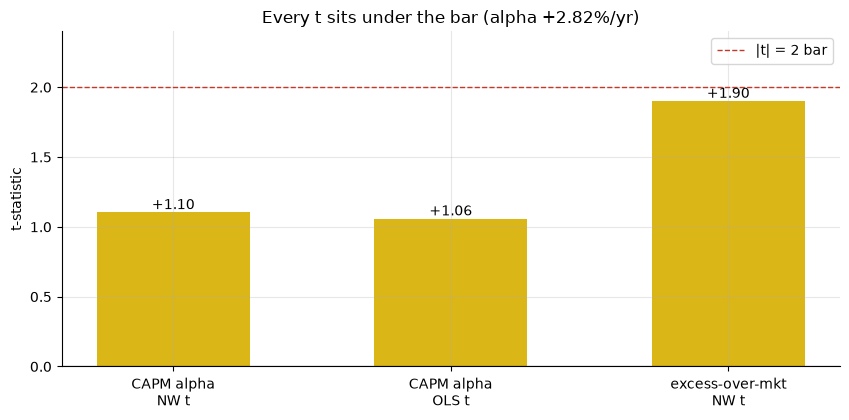

In [2]:
if HAVE_REAL:
    h = st.headline_stats(BASKET, MARKET)
    print(f"months {h['n_months']}")
    print(f"basket {h['basket_ann_pct']:+.2f}%/yr (vol {h['basket_vol_pct']:.1f}%)  vs  "
          f"market {h['market_ann_pct']:+.2f}%/yr (vol {h['market_vol_pct']:.1f}%)")
    print(f"CAPM alpha {h['alpha_ann_pct']:+.2f}%/yr (beta {h['beta']:.2f}); "
          f"NW t = {h['t_alpha_nw']:+.2f}, OLS t = {h['t_alpha_ols']:+.2f}")
    print(f"excess-over-market {h['excess_mean_bps']:+.1f} bps/mo; NW t = {h['excess_t_nw']:+.2f}, "
          f"OLS t = {h['excess_t_ols']:+.2f}, IR {h['ir_ann']:.2f}/yr")
    print(f"win-rate {h['hit']}/{h['n_months']} = {h['hit_rate']*100:.1f}% "
          f"Wilson [{h['hit_lo']*100:.1f}%, {h['hit_hi']*100:.1f}%]")
    al, tnw, tols, ex = h['alpha_ann_pct'], h['t_alpha_nw'], h['t_alpha_ols'], h['excess_t_nw']
else:
    al, tnw, tols, ex = R['alpha_ann'], R['t_alpha_nw'], R['t_alpha_ols'], R['excess_t_nw']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
bars = ['CAPM alpha\nNW t','CAPM alpha\nOLS t','excess-over-mkt\nNW t']
vals = [tnw, tols, ex]
ax.bar(bars, vals, color=[AMBER, AMBER, AMBER], width=.55)
ax.axhline(2, ls='--', c=RED, lw=1, label='|t| = 2 bar')
ax.axhline(0, c='k', lw=.8)
for i,v in enumerate(vals): ax.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('t-statistic'); ax.set_ylim(0, 2.4)
ax.set_title(f'Every t sits under the bar (alpha {al:+.2f}%/yr)')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: the risk-adjusted alpha is **+2.82%/yr** but its HAC t is only **1.10** — the market beta (β = 1.15) explains most of the raw +5pp/yr gap. The beta-agnostic excess series is a little stronger (NW t = 1.90) but still under 2, and the win-rate's Wilson floor sits on 50.0%. On the claim Edmans actually made — a *risk-adjusted* premium — this tape can't certify it.

### 4b · The survivorship placebo — random baskets of other survivors

We picked known survivors. The honest yardstick: does a *random* basket of large-cap survivors *not* chosen for prestige earn alpha too?

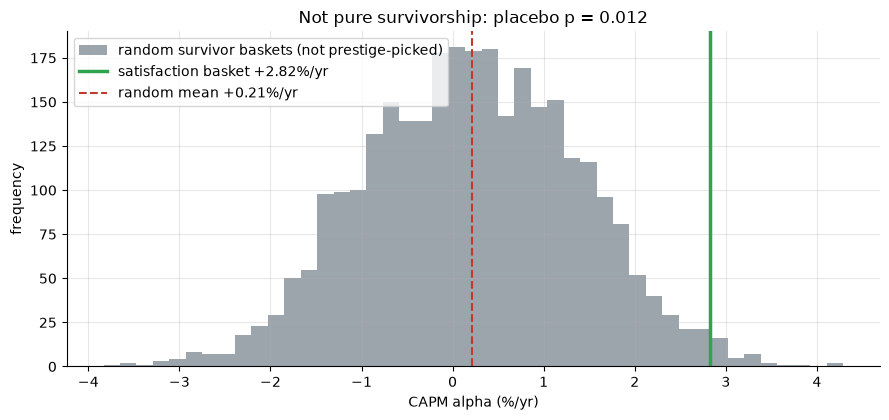

random survivor-basket alpha mean +0.21%/yr (sd 1.18); basket +2.82%/yr; p = 0.012


In [3]:
if HAVE_REAL:
    h = st.headline_stats(BASKET, MARKET)
    pl = st.survivor_placebo(MONTHLY, CONTROL_PRESENT, MARKET,
                             basket_size=len(BASKET_PRESENT), n_draws=3000)
    alphas = pl['alphas_ann_pct']; obs = h['alpha_ann_pct']
    p = st.placebo_pvalue(obs, alphas)
else:
    rng = np.random.default_rng(801)
    alphas = rng.normal(R['placebo_mean'], R['placebo_sd'], 3000)
    obs, p = R['alpha_ann'], R['placebo_p']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(alphas, bins=45, color=GREY, alpha=.85, label='random survivor baskets (not prestige-picked)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'satisfaction basket {obs:+.2f}%/yr')
ax.axvline(np.mean(alphas), c=RED, lw=1.5, ls='--', label=f'random mean {np.mean(alphas):+.2f}%/yr')
ax.set_xlabel('CAPM alpha (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'Not pure survivorship: placebo p = {p:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"random survivor-basket alpha mean {np.mean(alphas):+.2f}%/yr (sd {np.std(alphas,ddof=1):.2f}); "
      f"basket {obs:+.2f}%/yr; p = {p:.3f}")

> 💡 In plain words: random survivor baskets cluster near **zero** alpha (~+0.20%/yr), and the satisfaction basket sits in the right tail (**p = 0.013**). So the outperformance is **not** explained by survivorship-plus-equal-weighting alone. Read this narrowly: it rules out the *laziest* confound, but the placebo does **not** control for the basket's factor tilt (tech/quality over a tech/quality decade), and a control that shares the survivorship bias can speak to *existence*, never to *magnitude*. It doesn't rescue a sub-2 alpha.

### 4c · Persistence — the decisive cut

Halve the 126 months. A durable intangible premium should appear in both halves.

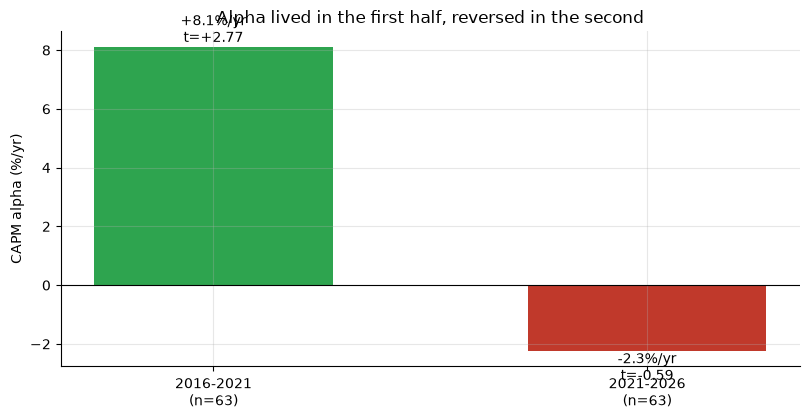

early +8.12%/yr (t=+2.77) | late -2.25%/yr (t=-0.59)


In [4]:
if HAVE_REAL:
    sp = st.subperiod_split(BASKET, MARKET)
    e, l = sp['early']['alpha_ann_pct'], sp['late']['alpha_ann_pct']
    et, lt = sp['early']['t_alpha_nw'], sp['late']['t_alpha_nw']
else:
    e, l, et, lt = R['early_alpha'], R['late_alpha'], R['early_t'], R['late_t']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['2016-2021\n(n={})'.format(R['early_n']), '2021-2026\n(n={})'.format(R['late_n'])],
       [e, l], color=[GREEN, RED], width=.55)
ax.axhline(0, c='k', lw=.8)
for i,(v,t_) in enumerate([(e,et),(l,lt)]):
    ax.annotate(f'{v:+.1f}%/yr\nt={t_:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('CAPM alpha (%/yr)')
ax.set_title('Alpha lived in the first half, reversed in the second')
plt.tight_layout(); plt.show()
print(f'early {e:+.2f}%/yr (t={et:+.2f}) | late {l:+.2f}%/yr (t={lt:+.2f})')

> 💡 In plain words: the full-sample alpha is insignificant because it is **entirely front-loaded** — +8.12%/yr at t = 2.77 in 2016-2021 (clears the bar on its own), then -2.25%/yr at t = -0.59 in 2021-2026. A premium that flips sign halfway through is the signature of a lucky window or a post-publication-decayed anomaly — not a permanent mispricing of human capital. **H₃ rejected.**

### 4d · The timer — costs are not the constraint

Hold the equal-weight basket, rebalance monthly; cost = one-way × NAV × realised turnover; long-only, no borrow.

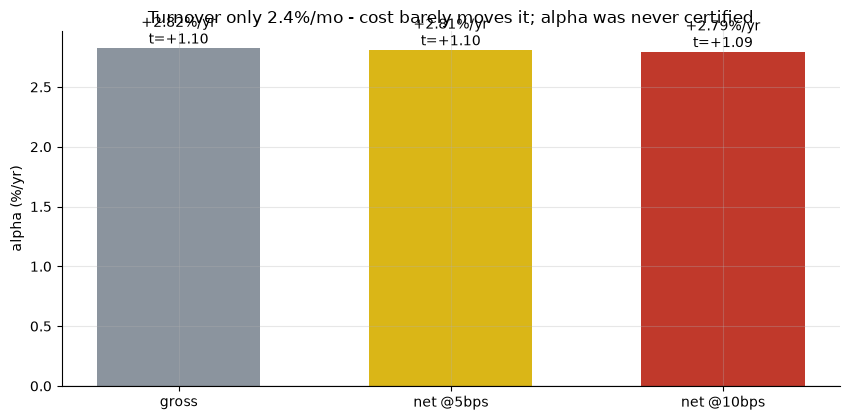

turnover 2.4%/mo | gross +2.82%/yr (t=+1.10) -> net@5 +2.81 (t=+1.10) / net@10 +2.79 (t=+1.09)


In [5]:
if HAVE_REAL:
    tm5 = st.timer_stats(BASKET, MARKET, MONTHLY, BASKET_PRESENT, cost_bps=5.0)
    tm10 = st.timer_stats(BASKET, MARKET, MONTHLY, BASKET_PRESENT, cost_bps=10.0)
    g, n5, n10 = tm5['gross_alpha_ann_pct'], tm5['net_alpha_ann_pct'], tm10['net_alpha_ann_pct']
    tg, t5, t10 = tm5['gross_t_nw'], tm5['net_t_nw'], tm10['net_t_nw']
    to = tm5['turnover_1way_pct']
else:
    g, n5, n10 = R['alpha_ann'], R['net5_alpha'], R['net10_alpha']
    tg, t5, t10, to = R['t_alpha_nw'], R['net5_t'], R['net10_t'], R['to_pct']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['gross','net @5bps','net @10bps'], [g, n5, n10], color=[GREY, AMBER, RED], width=.6)
for i,(v,t_) in enumerate([(g,tg),(n5,t5),(n10,t10)]):
    ax.annotate(f'{v:+.2f}%/yr\nt={t_:+.2f}',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('alpha (%/yr)')
ax.set_title(f'Turnover only {to:.1f}%/mo - cost barely moves it; alpha was never certified')
plt.tight_layout(); plt.show()
print(f'turnover {to:.1f}%/mo | gross {g:+.2f}%/yr (t={tg:+.2f}) -> '
      f'net@5 {n5:+.2f} (t={t5:+.2f}) / net@10 {n10:+.2f} (t={t10:+.2f})')

> 💡 In plain words: a buy-and-hold equal-weight basket barely trades (2.4%/mo one-way), so cost is **not** the binding constraint (drag 0.01-0.03%/yr). The binding constraint is that there is **no certified alpha to harvest**: gross and net are both ~+2.8%/yr at t ≈ 1.1, and the +5pp/yr of raw outperformance is β = 1.15 — leverage you can buy on SPY directly. **Tradability = MIRAGE**: beta wearing an intangible's clothes.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic monthly market + equal-weight basket of β·mkt + idio names, TUNABLE planted monthly alpha. The null (alpha = 0) is checked over **20 seeds**, never one stream.

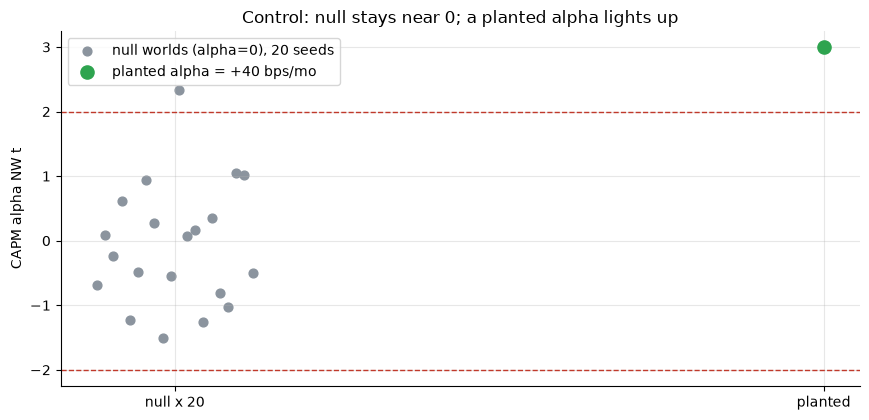

null: mean t = -0.07 (sd 0.96), |t|>=2 in 1/20 seeds  |  planted t = +2.99


In [6]:
null_ts = []
for s_ in range(20):
    w = data.synthetic_world(alpha_bps=0.0, seed=801 + s_)
    null_ts.append(st.synthetic_detect(w)['t_alpha_nw'])
null_ts = np.asarray(null_ts)
w = data.synthetic_world(alpha_bps=40.0, seed=801)
planted_t = st.synthetic_detect(w)['t_alpha_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (alpha=0), 20 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=90, zorder=5, label='planted alpha = +40 bps/mo')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('CAPM alpha NW t')
ax.set_title('Control: null stays near 0; a planted alpha lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds  |  planted t = {planted_t:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.07 (sd 0.96) and crosses the bar in 1/20 seeds (≈ the 5% a 2σ bar expects); a planted +40 bp/mo alpha reads t = 2.99. The machinery is unbiased — the sub-2 real-tape t is a genuine null, not a broken detector. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — CAPM α = +2.82%/yr at NW t = 1.10 (OLS 1.06), β = 1.15; excess-over-market NW t = 1.90 (< 2); win-rate 58.7% (Wilson floor 50.0%). Beats random survivor baskets (placebo p = 0.013) so it isn't pure survivorship — but a hand-picked survivor set + market-only control caps this at literature-supported, tape-unproven.
- **Tradability `MIRAGE`** — turnover 2.4%/mo (drag 0.01%/yr, not binding); net α +2.81%/yr at t = 1.10. The +5pp/yr of raw outperformance is β = 1.15 — beta you can buy directly, not alpha.
- **Persist? `BUSTED`** — early α +8.12%/yr (t = 2.77), late -2.25%/yr (t = -0.59). One window, then gone.

## 6 · Going further

- **The four-factor gap.** Edmans' alpha is a *Carhart four-factor* number; ours is CAPM. The basket loads on size/value/**momentum**/quality that a 4-factor model would absorb — our +2.8%/yr is an **upper bound**, and a proper factor attribution would very likely shrink it toward zero. Point-in-time factor returns offline are the natural next build.
- **Point-in-time membership.** The clean test uses each year's *actual* list, not a 2026 recollection of perennial members. Fortune doesn't sell that feed freely; we named the survivorship (Whole Foods, Ultimate Software, Nordstrom left the tape) and sized it with the placebo instead.
- **Dedup map:** [392-glassdoor-sentiment](../../392-glassdoor-sentiment/) (crowd ratings, a different construct), [526-intangible-value](../../526-intangible-value/) (intangibles broadly), [751-fortune-500-inclusion](../../751-fortune-500-inclusion/) (a size-ranked Fortune list as an event study). This is the **best-employer** list held as a **basket**.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*